# AI4I Predictive Maintenance

## Stage 1 — Failure Prediction

### Study dataset

In [4]:
import pandas as pd

In [5]:
# Import dataset
df = pd.read_csv('ai4i2020.csv')
df.head(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


In [6]:
# Verify shape of dataframe
df.shape

(10000, 14)

In [7]:
# Verify info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [8]:
# Verify some basic statistics about dataset
df.describe(include='all')

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
unique,NaN,10000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,M14860,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,NaN,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,NaN,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,NaN,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,NaN,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,NaN,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,NaN,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


In [9]:
# Verify the number of failures 
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [10]:
# Verify proportion of failures 
df['Machine failure'].value_counts(normalize = True)

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

In [11]:
#Verify the number of failures by each failure mode
df[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum().sort_values(ascending=False)

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

##### Note: The most part of failures are related to: HDF, OSF and PWF

In [13]:
# Check if it is possible having more than one failure mode associate to a failure
df[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum(axis=1).value_counts().sort_index()

0    9652
1     324
2      23
3       1
Name: count, dtype: int64

##### Note: It is possible to have more than one type of failure at the same time. We have 324 failures associate to one failure mode, 23 associate to two failure modes and 1 failure associate to three different failure modes.

In [15]:
# Check if the dataset has an observation with "Machine failure" = 0 and one or more failure modes = 1.
# Since it has 339 "Machine failure" x 348 failure modes.
df[
(df['Machine failure'] == 0) &
(df[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum(axis=1) > 0)]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
1221,1222,M16081,M,297.0,308.3,1399,46.4,132,0,0,0,0,0,1
1302,1303,L48482,L,298.6,309.8,1505,45.7,144,0,0,0,0,0,1
1748,1749,H31162,H,298.4,307.7,1626,31.1,166,0,0,0,0,0,1
2072,2073,L49252,L,299.6,309.5,1570,35.5,189,0,0,0,0,0,1
2559,2560,L49739,L,299.3,309.0,1447,50.4,140,0,0,0,0,0,1
3065,3066,M17925,M,300.1,309.2,1687,27.7,95,0,0,0,0,0,1
3452,3453,H32866,H,301.6,310.5,1602,32.3,2,0,0,0,0,0,1
5471,5472,L52651,L,302.7,312.3,1346,61.2,170,0,0,0,0,0,1
5489,5490,L52669,L,302.6,312.1,1499,35.0,215,0,0,0,0,0,1
5495,5496,H34909,H,302.9,312.5,1357,55.0,12,0,0,0,0,0,1


##### By the filter, we noticed that there are observations where the failure mode "RNF" is inputed while a "Machine failure" is not detected 

In [17]:
# Sum how many RNF = 1 are detected for Machine failure = 0 
len(df[
(df['Machine failure'] == 0) &
(df['RNF'] == 1)])

18

In [18]:
# Verify if there are observations with "Machine failure" = 1 and no failure modes detected.
len(
    df[
    (df['Machine failure'] == 1) &
    (df[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum(axis=1) == 0)]
)

9

##### There are 9 rows where a failure is detected but no failure mode is associated to.

### Study the features

In [21]:
# Verify the correlation of numerical features with "Machine failure"
df.corr(numeric_only=True)['Machine failure'].sort_values(ascending=False)

Machine failure            1.000000
HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
RNF                        0.004516
UDI                       -0.022892
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64

In [22]:
# Verify the correlation among the operational conditions 
df[["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
    "Torque [Nm]", "Tool wear [min]"]].corr()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000


##### Air temperature and process temperature has a highly positive correlation (Expected by the way the dataset was generated). Rotational speed and torque has a highly negative correlation, also expected by the relation between them assuming a constant power (P=T.w = (T.n.2.pi)/60). Finally, Tool wear has pratically no correlation with other opertional conditions.

In [24]:
features = ["Air temperature [K]", "Process temperature [K]","Rotational speed [rpm]",
            "Torque [Nm]","Tool wear [min]"]

In [25]:
df.groupby('Machine failure')[features].describe().T

Machine failure                          0            1
Air temperature [K]     count  9661.000000   339.000000
                        mean    299.973999   300.886431
                        std       1.990748     2.071473
                        min     295.300000   295.600000
                        25%     298.300000   299.100000
                        50%     300.000000   301.600000
                        75%     301.500000   302.500000
                        max     304.500000   304.400000
Process temperature [K] count  9661.000000   339.000000
                        mean    309.995570   310.290265
                        std       1.486846     1.363686
                        min     305.700000   306.100000
                        25%     308.800000   309.500000
                        50%     310.000000   310.400000
                        75%     311.100000   311.200000
                        max     313.800000   313.700000
Rotational speed [rpm]  count  9661.000000   339.000000
                        mean   1540.260014  1496.486726
                        std     167.394734   384.943547
                        min    1168.000000  1181.000000
                        25%    1429.000000  1326.500000
                        50%    1507.000000  1365.000000
                        75%    1615.000000  1421.500000
                        max    2695.000000  2886.000000
Torque [Nm]             count  9661.000000   339.000000
                        mean     39.629655    50.168142
                        std       9.472080    16.374498
                        min      12.600000     3.800000
                        25%      33.100000    45.950000
                        50%      39.900000    53.700000
                        75%      46.300000    61.200000
                        max      70.000000    76.600000
Tool wear [min]         count  9661.000000   339.000000
                        mean    106.693717   143.781711
                        std      62.945790    72.759876
                        min       0.000000     0.000000
                        25%      52.000000    84.500000
                        50%     107.000000   165.000000
                        75%     160.000000   207.500000
                        max     246.000000   253.000000

##### High dispersion detected for rotational speed for machines that fail, it can indicate that extreme rotations can led to a failure. High torques look indicate a failure as well. Finally, the median of tool wear indicate a considerable difference between those machines that fail of those that not. Let's investigate more these variables.

In [27]:
import matplotlib.pyplot as plt

In [28]:
# Investigate the three operational conditions previously mentioned
operational_conditions = ['Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

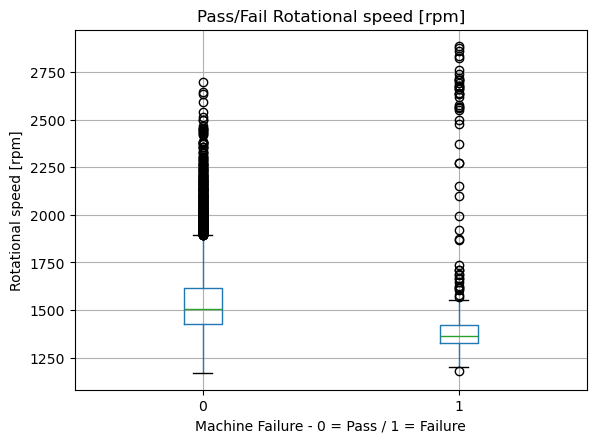

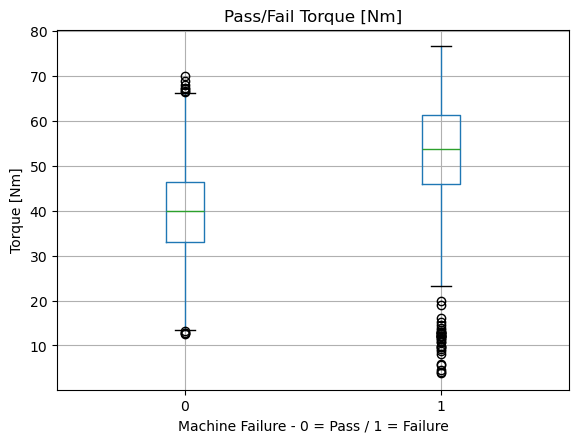

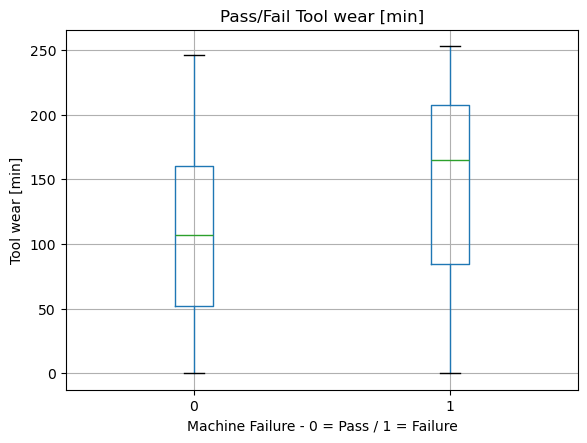

In [29]:
# Investigate the three operational conditions previously mentioned
for condition in operational_conditions:
    df.boxplot(column=condition, by='Machine failure')
    plt.title(f'Pass/Fail {condition}')
    plt.suptitle('')
    plt.xlabel('Machine Failure - 0 = Pass / 1 = Failure')
    plt.ylabel(condition)
    plt.show()

##### Regarding rotational speed, there are many outliers for both non-failing and failing machines. The central 50% of the data for this variable do not overlap; generally speaking, failures occur at lower speeds (approx. 1300–1400 rpm), although we must not overlook the many outliers at higher speeds. Furthermore, there appears to be a threshold (around 2500 rpm) where the quantity of failures look exceed the number of non-failures - Maybe we should investigate the failure tax in this threshold to confirm it.
##### The torque variable also presents a significant number of outliers. The boxes do not overlap here either, and it is evident that the central 50% of failure cases are associated with higher torque values. The number of outliers associated with low-torque failures is also noteworthy and should not be ignored. (It might be useful to create a feature combining rpm and torque to analyze failures based on that metric).
##### Regarding tool wear, there is considerable overlap between the non-failure and failure groups. However, a threshold is also visible where failures are more frequent than non-failures (approx. 160 min) - Similar to Rotational speed, we should investigate the failure tax in this threshold to confirm it.

In [31]:
# Investigate rotational speed
import numpy as np

bins = np.linspace(
    df["Rotational speed [rpm]"].min(),
    df["Rotational speed [rpm]"].max(),
    11)

df["RPM range"] = pd.cut(df["Rotational speed [rpm]"], bins=bins, include_lowest=True)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,RPM range
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,"(1511.6, 1683.4]"
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,"(1339.8, 1511.6]"
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,"(1339.8, 1511.6]"
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,"(1339.8, 1511.6]"
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,"(1339.8, 1511.6]"


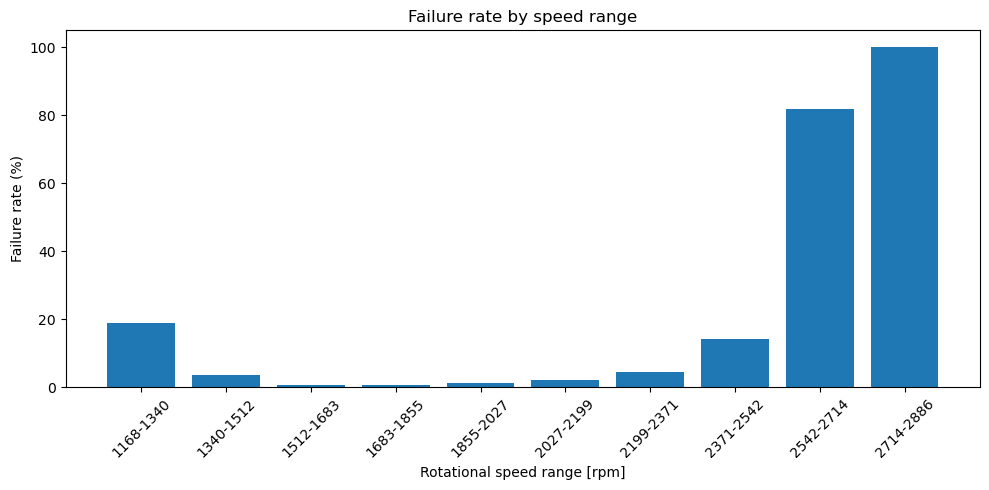

In [32]:
# Investigate rotational speed
failure_rate = df.groupby("RPM range", observed=True)["Machine failure"].mean()

plt.figure(figsize=(10, 5))

plt.bar(
    range(len(failure_rate)),
    failure_rate * 100,
    width=0.8
)

plt.xticks(
    range(len(failure_rate)),
    [f"{interval.left:.0f}-{interval.right:.0f}" for interval in failure_rate.index],
    rotation=45
)

plt.xlabel("Rotational speed range [rpm]")
plt.ylabel("Failure rate (%)")
plt.title("Failure rate by speed range")
plt.tight_layout()
plt.show()

In [33]:
# Investigate rotational speed
df.groupby("RPM range", observed=True)["Machine failure"].agg(
    ["count", "sum", "mean"])

,count,sum,mean
RPM range,,,
"(1167.999, 1339.8]",602,113,0.187708
"(1339.8, 1511.6]",4650,168,0.036129
"(1511.6, 1683.4]",3227,16,0.004958
"(1683.4, 1855.2]",987,5,0.005066
"(1855.2, 2027.0]",337,4,0.011869
"(2027.0, 2198.8]",101,2,0.019802
"(2198.8, 2370.6]",45,2,0.044444
"(2370.6, 2542.4]",21,3,0.142857
"(2542.4, 2714.2]",22,18,0.818182


##### Boxplot: Many failures happening in low RPMs (Absolute Frequency);
##### Proportional graphic and table: Proportionally, we have high rates of failures in high RPMs.
##### Attention to extreme RPMs

In [35]:
# Investigate Torque
bins_torque = np.linspace(
            df['Torque [Nm]'].min(),
            df['Torque [Nm]'].max(),
            11)

df['Torque Range'] = pd.cut(df['Torque [Nm]'], bins = bins_torque, include_lowest=True)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,RPM range,Torque Range
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,"(1511.6, 1683.4]","(40.2, 47.48]"
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,"(1339.8, 1511.6]","(40.2, 47.48]"
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,"(1339.8, 1511.6]","(47.48, 54.76]"
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,"(1339.8, 1511.6]","(32.92, 40.2]"
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,"(1339.8, 1511.6]","(32.92, 40.2]"


In [36]:
df.groupby('Torque Range', observed=True)['Machine failure'].agg(['count', 'sum', 'mean'])

,count,sum,mean
Torque Range,,,
"(3.799, 11.08]",13,13,1.000000
"(11.08, 18.36]",137,19,0.138686
"(18.36, 25.64]",614,5,0.008143
"(25.64, 32.92]",1666,10,0.006002
"(32.92, 40.2]",2597,15,0.005776
"(40.2, 47.48]",2697,36,0.013348
"(47.48, 54.76]",1624,88,0.054187
"(54.76, 62.04]",521,78,0.149712
"(62.04, 69.32]",112,57,0.508929


##### Torque looks like RPM in terms of "extreme" values can indicate a possible high risk of failure

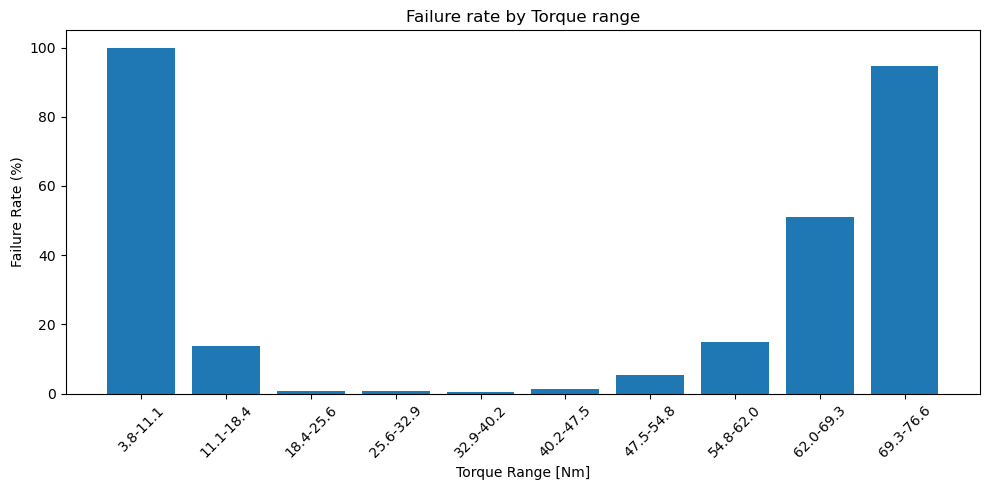

In [38]:
# Investigate Torque
plt.figure(figsize=(10, 5))

plt.bar(
    range(len(df.groupby("Torque Range", observed=True)["Machine failure"].mean())),
    df.groupby("Torque Range", observed=True)["Machine failure"].mean() * 100
)

plt.xticks(
    range(len(df.groupby("Torque Range", observed=True)["Machine failure"].mean())),
    [
        f"{interval.left:.1f}-{interval.right:.1f}"
        for interval in df.groupby("Torque Range", observed=True)["Machine failure"].mean().index
    ],
    rotation=45
)

plt.xlabel("Torque Range [Nm]")
plt.ylabel("Failure Rate (%)")
plt.title("Failure rate by Torque range")
plt.tight_layout()
plt.show()

In [39]:
# Investigate Tool wear
bins_tool = np.linspace(
            df['Tool wear [min]'].min(),
            df['Tool wear [min]'].max(),
            11)

df['Tool wear Range'] = pd.cut(df['Tool wear [min]'], bins = bins_tool, include_lowest=True)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,RPM range,Torque Range,Tool wear Range
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,"(1511.6, 1683.4]","(40.2, 47.48]","(-0.001, 25.3]"
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,"(1339.8, 1511.6]","(40.2, 47.48]","(-0.001, 25.3]"
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,"(1339.8, 1511.6]","(47.48, 54.76]","(-0.001, 25.3]"
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,"(1339.8, 1511.6]","(32.92, 40.2]","(-0.001, 25.3]"
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,"(1339.8, 1511.6]","(32.92, 40.2]","(-0.001, 25.3]"


In [40]:
# Investigate Tool wear
df.groupby('Tool wear Range', observed=True)['Machine failure'].agg(['count', 'sum', 'mean'])

,count,sum,mean
Tool wear Range,,,
"(-0.001, 25.3]",1256,32,0.025478
"(25.3, 50.6]",1140,20,0.017544
"(50.6, 75.9]",1140,26,0.022807
"(75.9, 101.2]",1179,30,0.025445
"(101.2, 126.5]",1146,26,0.022688
"(126.5, 151.8]",1139,22,0.019315
"(151.8, 177.1]",1191,26,0.021830
"(177.1, 202.4]",1137,44,0.038698
"(202.4, 227.7]",613,93,0.151713


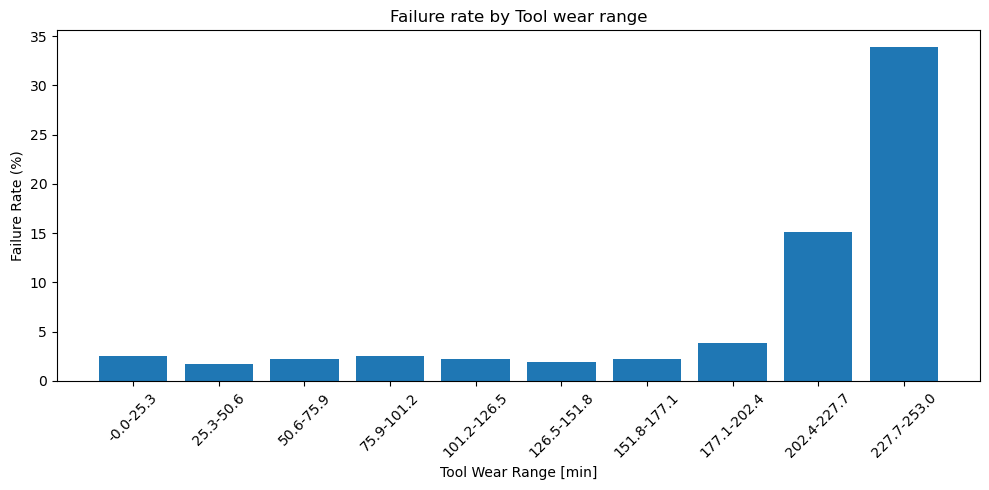

In [41]:
# Investigate Tool wear
plt.figure(figsize=(10, 5))

plt.bar(
    range(len(df.groupby("Tool wear Range", observed=True)["Machine failure"].mean())),
    df.groupby("Tool wear Range", observed=True)["Machine failure"].mean() * 100
)

plt.xticks(
    range(len(df.groupby("Tool wear Range", observed=True)["Machine failure"].mean())),
    [
        f"{interval.left:.1f}-{interval.right:.1f}"
        for interval in df.groupby("Tool wear Range", observed=True)["Machine failure"].mean().index
    ],
    rotation=45
)

plt.xlabel("Tool Wear Range [min]")
plt.ylabel("Failure Rate (%)")
plt.title("Failure rate by Tool wear range")
plt.tight_layout()
plt.show()

##### Tool wear has a different behaviour when compared with RPM and Torque, it has a constant behaviour until about 177min of accumulated wear and then, the rate of failures starts to increase considerably. It brings a better look for us of the first impression about Tool Wear around 160min appears increase the risk, it was not totally right.

##### Let's investigate the categorical variable "Type"

In [44]:
# Investigate Type
df.groupby('Type', observed = True)['Machine failure'].agg(['count', 'sum', 'mean'])

,count,sum,mean
Type,,,
H,1003,21,0.020937
L,6000,235,0.039167
M,2997,83,0.027694


##### This metric looks follow a linear behaviour related to "quality" vs "failure", but individually, it looks to impact less or in a less evident way the failures than RPM, Torque and Tool wear

##### Let's investigate the last parameter: Temperature

In [47]:
# Investigate Temperature
bins_temperature = np.linspace(
                    df['Process temperature [K]'].min(),
                    df['Process temperature [K]'].max(),
                    11)

df['Process Temperature Range'] = pd.cut(df['Process temperature [K]'], bins = bins_temperature, include_lowest = True)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,RPM range,Torque Range,Tool wear Range,Process Temperature Range
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,"(1511.6, 1683.4]","(40.2, 47.48]","(-0.001, 25.3]","(308.13, 308.94]"
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,"(1339.8, 1511.6]","(40.2, 47.48]","(-0.001, 25.3]","(308.13, 308.94]"
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,"(1339.8, 1511.6]","(47.48, 54.76]","(-0.001, 25.3]","(308.13, 308.94]"
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,"(1339.8, 1511.6]","(32.92, 40.2]","(-0.001, 25.3]","(308.13, 308.94]"
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,"(1339.8, 1511.6]","(32.92, 40.2]","(-0.001, 25.3]","(308.13, 308.94]"


In [48]:
df.groupby('Process Temperature Range', observed = True)['Machine failure'].agg(['count', 'sum', 'mean'])

,count,sum,mean
Process Temperature Range,,,
"(305.699, 306.51]",98,3,0.030612
"(306.51, 307.32]",123,2,0.016260
"(307.32, 308.13]",843,23,0.027284
"(308.13, 308.94]",1655,38,0.022961
"(308.94, 309.75]",1692,26,0.015366
"(309.75, 310.56]",1724,89,0.051624
"(310.56, 311.37]",1944,83,0.042695
"(311.37, 312.18]",1141,53,0.046450
"(312.18, 312.99]",528,16,0.030303


##### In terms of behaviour of variable, I could not identify any pattern for Temperature. It looks to impact less or in a less evident way the failures than RPM, Torque and Tool wear

#### Feature Engineering

In [51]:
# Create a column that relates Torque and RPM
df['Power [W]'] = (df['Torque [Nm]'] * ((2 * np.pi * df['Rotational speed [rpm]']) / 60))
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,RPM range,Torque Range,Tool wear Range,Process Temperature Range,Power [W]
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,"(1511.6, 1683.4]","(40.2, 47.48]","(-0.001, 25.3]","(308.13, 308.94]",6951.590560
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,"(1339.8, 1511.6]","(40.2, 47.48]","(-0.001, 25.3]","(308.13, 308.94]",6826.722724
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,"(1339.8, 1511.6]","(47.48, 54.76]","(-0.001, 25.3]","(308.13, 308.94]",7749.387543
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,"(1339.8, 1511.6]","(32.92, 40.2]","(-0.001, 25.3]","(308.13, 308.94]",5927.504659
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,"(1339.8, 1511.6]","(32.92, 40.2]","(-0.001, 25.3]","(308.13, 308.94]",5897.816608


In [52]:
# Investigate Power
df.groupby('Machine failure')['Power [W]'].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,6244.547534,1011.394393,3515.033772,5549.309263,6243.046225,6952.051327,8998.024015
1,339.0,7282.819485,1851.137977,1148.440610,6669.056661,7611.429737,8548.854805,10469.923005


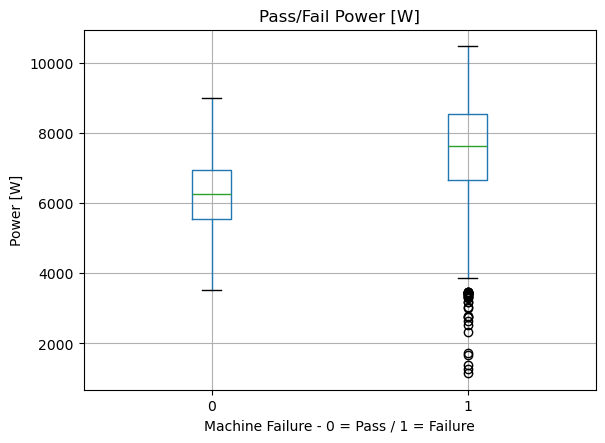

In [53]:
# Investigate Power
df.boxplot(column='Power [W]', by='Machine failure')
plt.title(f'Pass/Fail Power [W]')
plt.suptitle('')
plt.xlabel('Machine Failure - 0 = Pass / 1 = Failure')
plt.ylabel('Power [W]')
plt.show()

##### Interesting result, specially for non-failures machines. There are no outliers, what can indicate a region of minor risk of failure. Let's investigate more about it.

In [55]:
# How many failures are out of the "safe" power range?
((df['Power [W]'] < 3515) | (df['Power [W]'] > 8998.1)).sum()

95

In [56]:
# In proportion, how much failure happen out of the "safe" power range?
95 / df['Machine failure'].sum()   

0.28023598820059

In [57]:
# Investigate Power
power_bins = np.linspace(
                df['Power [W]'].min(),
                df['Power [W]'].max(),
                11)

df['Power Range'] = pd.cut(df['Power [W]'], bins = power_bins, include_lowest=True)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,RPM range,Torque Range,Tool wear Range,Process Temperature Range,Power [W],Power Range
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,"(1511.6, 1683.4]","(40.2, 47.48]","(-0.001, 25.3]","(308.13, 308.94]",6951.590560,"(6741.33, 7673.478]"
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,"(1339.8, 1511.6]","(40.2, 47.48]","(-0.001, 25.3]","(308.13, 308.94]",6826.722724,"(6741.33, 7673.478]"
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,"(1339.8, 1511.6]","(47.48, 54.76]","(-0.001, 25.3]","(308.13, 308.94]",7749.387543,"(7673.478, 8605.627]"
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,"(1339.8, 1511.6]","(32.92, 40.2]","(-0.001, 25.3]","(308.13, 308.94]",5927.504659,"(5809.182, 6741.33]"
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,"(1339.8, 1511.6]","(32.92, 40.2]","(-0.001, 25.3]","(308.13, 308.94]",5897.816608,"(5809.182, 6741.33]"


In [58]:
df.groupby('Power Range', observed=True)['Machine failure'].agg(['count', 'sum', 'mean'])

,count,sum,mean
Power Range,,,
"(1148.44, 2080.589]",5,5,1.000000
"(2080.589, 3012.737]",7,7,1.000000
"(3012.737, 3944.885]",119,20,0.168067
"(3944.885, 4877.034]",804,4,0.004975
"(4877.034, 5809.182]",2337,17,0.007274
"(5809.182, 6741.33]",3415,38,0.011127
"(6741.33, 7673.478]",2379,82,0.034468
"(7673.478, 8605.627]",783,87,0.111111
"(8605.627, 9537.775]",137,65,0.474453


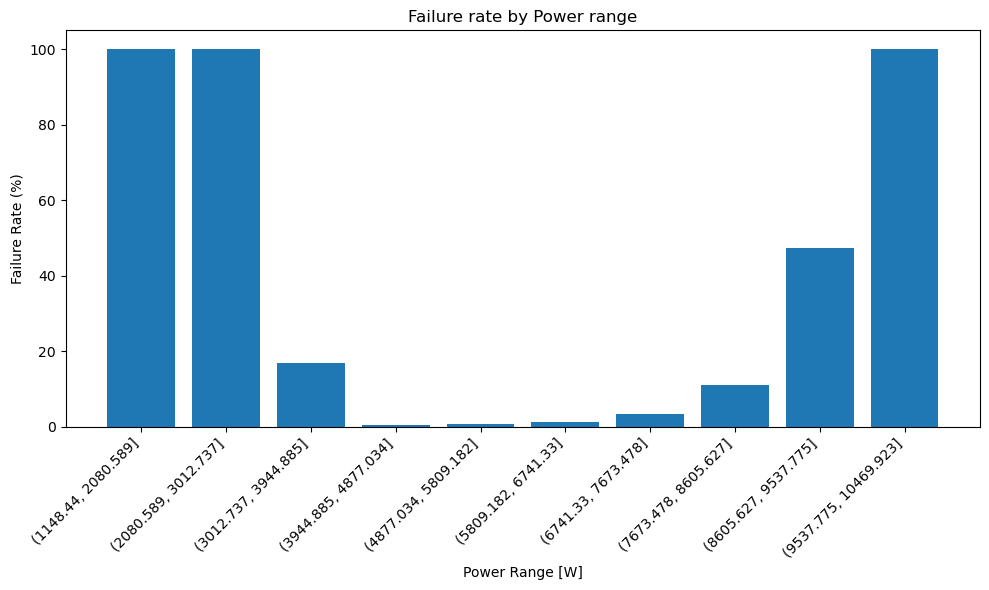

In [59]:
plt.figure(figsize=(10, 6))

plt.bar(df.groupby('Power Range', observed=True)['Machine failure'].mean().index.astype(str),
       df.groupby('Power Range', observed=True)['Machine failure'].mean() * 100)

plt.xticks(rotation=45, ha='right')

plt.xlabel("Power Range [W]")
plt.ylabel("Failure Rate (%)")
plt.title("Failure rate by Power range")
plt.tight_layout()
plt.show()

##### Like torque and RPM, Power - which is derived from the relationship between these two variables - has a behaviour that can indicate that extremes are, in general, associated with a higher risk of failure. Additionally, the new feature demonstrated an interesting pattern for non-failing equipments, with no outliers. Another important information is: 28% of all failures occurred outside the power range observed for non-failing equipment, which is very relevant, it may provide a valuable information for predicting macine failures.
##### We will keep this feature in mind for development the predictive model.

#### Select Features & Separate Dataset

In [62]:
# Define features and label/target
features = ['Type', 'Air temperature [K]', 'Process temperature [K]',
    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Power [W]']

target = 'Machine failure'

In [63]:
# Define features and label/target
X = df[features]
y = df[target]

In [64]:
# Separate data in train / test sets
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=0)

In [65]:
[X_train.shape, X_test.shape, y_train.shape, y_test.shape]

[(8000, 7), (2000, 7), (8000,), (2000,)]

In [66]:
X_train.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Power [W]'],
      dtype='object')

In [67]:
# Check stratification
print(f'Train proportion: {y_train.value_counts(normalize=True)}')
print('------------------------------------')
print(f'Test proportion: {y_test.value_counts(normalize=True)}')

Train proportion: Machine failure
0    0.966125
1    0.033875
Name: proportion, dtype: float64
------------------------------------
Test proportion: Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


In [68]:
categorical_features = ['Type']

numerical_features = ['Air temperature [K]', 'Process temperature [K]',
    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Power [W]']

In [69]:
# Treat categorical variable
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [70]:
# Treat categorical variable
preprocessor = ColumnTransformer(transformers = [('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
                                 remainder='passthrough', force_int_remainder_cols=False)

In [71]:
# Import Pipeline and classifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [72]:
# Create Pipeline
rf_pipeline = Pipeline(steps = [
                        ('preprocessor', preprocessor),
                        ('model', RandomForestClassifier(n_estimators=100, random_state=0))])

In [73]:
# Process data and Train the model
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('model', RandomForestClassifier(random_state=0))])

In [74]:
# Predict test data with trained model
y_pred = rf_pipeline.predict(X_test)

In [75]:
# Verify the predictions quality
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.96      0.74      0.83        68

    accuracy                           0.99      2000
   macro avg       0.98      0.87      0.91      2000
weighted avg       0.99      0.99      0.99      2000



##### Accuracy is not a useful metric for our project once our target is imbalanced, if the model predict all observations as non-failure, it will be correct for around 96%, but it would not be useful to detect the failures. Therefore, we will use "Precision", "Recall" and "F1-score" as metrics to evaluate the model.
##### Precision (How many failures detected by model were actually failures?) - The model has an interesting performance in this metric, 96% of observations detected as a failure really was a failure.
##### Recall (How many failures the model were able to detect?) - In this metric the model has a worse performance when compared with precision. According to our report, the model was able to detect 74% of failures, it means that we still have 26% of failures not detected.
##### F1-Score (Harmonic mean between precision and recall) - Currently the model has 83% in this metric that tries equilibrating precision and recall.
##### Conclusion: An interesting start, but let's try improving the model adjusting model parameters and/or the class imbalance. We need to improve recall and try not lose performance in precision.

In [77]:
# Update model parameter trying to improve it. Parameter: "class_weight=balanced"
rf_pipeline.set_params(model__class_weight='balanced')
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=0))])

In [78]:
# Predict with new model (Class_weight='balanced')
y_pred = rf_pipeline.predict(X_test)

In [79]:
# Verify the efficiency of new model (Class_weight='balanced')
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.91      0.60      0.73        68

    accuracy                           0.98      2000
   macro avg       0.95      0.80      0.86      2000
weighted avg       0.98      0.98      0.98      2000



##### Adjusting the parameter "class_weight" did not improve the model, instead of this, the metrics got worse. Let's try other type of improvements.

In [81]:
# Back the model to baseline (class_weight='None')
rf_pipeline.set_params(model__class_weight=None)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('model', RandomForestClassifier(random_state=0))])

In [82]:
# Search for better parameters for our classifier
from sklearn.model_selection import GridSearchCV

In [83]:
# Search for better parameters for our classifier
grid_parameters = {
                'model__n_estimators': [100, 200, 300],
                'model__max_depth': [None, 10, 20],
                'model__min_samples_split': [2, 5],
                'model__min_samples_leaf': [1, 2, 5]}

In [84]:
# Search for better parameters for our classifier
grid_search = GridSearchCV(
                            estimator = rf_pipeline,
                            param_grid = grid_parameters,
                            scoring = 'recall',
                            cv = 5,
                            n_jobs = 1)

In [85]:
# Search for better parameters for our classifier
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Type'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=0))]),
             n_jobs=1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2, 5],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200, 300]},
             scoring='recall')

In [86]:
# Verify which parameters present better results for "recall"
grid_search.best_params_

{'model__max_depth': None,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 5,
 'model__n_estimators': 100}

In [87]:
# Verify the best "Recall" obtained for our best parameters
grid_search.best_score_

0.6385185185185185

In [88]:
# Predict using a model with the best parameters found by Gridsearchcv
best_rf = grid_search.best_estimator_

y_pred_grid = best_rf.predict(X_test)

In [89]:
# Verify the efficiency of new model (GridSearchCV)
print(classification_report(y_test, y_pred_grid))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.94      0.69      0.80        68

    accuracy                           0.99      2000
   macro avg       0.96      0.84      0.90      2000
weighted avg       0.99      0.99      0.99      2000



##### The optimization using GridSearchCV did not improve the model. Recall, precision and f1-score performed worse with new parameters than our started model. Interesting to note that the only parameter different from default in best grid was "min_sample_split": 2 for baseline and 5 for grid.
##### Baseline is still our best model.

In [91]:
# Verify if to treat the imbalancement on target can improve our model
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline

ros = RandomOverSampler(random_state=0)

In [92]:
# Create a new pipeline for ROS
rf_ros_pipeline = Pipeline(steps=[
                        ('preprocessor', preprocessor),
                        ('oversampler', ros),
                        ('model', RandomForestClassifier(n_estimators=100, random_state=0))])

In [93]:
# Train new model
rf_ros_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('oversampler', RandomOverSampler(random_state=0)),
                ('model', RandomForestClassifier(random_state=0))])

In [94]:
# Predict X_test
y_pred_ros = rf_ros_pipeline.predict(X_test)

In [95]:
# Check the efficiency of new model (ROS)
print(classification_report(y_test, y_pred_ros))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.82      0.72      0.77        68

    accuracy                           0.98      2000
   macro avg       0.90      0.86      0.88      2000
weighted avg       0.98      0.98      0.98      2000



##### RandomOverSampler also did not improve the model when compared with our first model (Baseline). Recall detected was 72% and precision decreased considerably from 96% in our baseline to 82% for ROS model.
##### Baseline is still the best model for our project - Recall: 74%, Precision: 96% and F1-score: 83%

In [97]:
# Check if SMOTE technique can improve the model
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)

In [98]:
# Create new Pipeline for SMOTE
rf_smote_pipeline = Pipeline(steps=[
                    ('preprocessor', preprocessor),
                    ('smote', smote),
                    ('model', RandomForestClassifier(n_estimators=100, random_state=0))])

In [99]:
# Train new model (SMOTE)
rf_smote_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('smote', SMOTE(random_state=0)),
                ('model', RandomForestClassifier(random_state=0))])

In [100]:
# Predict X_test with new model (SMOTE)
y_pred_smote = rf_smote_pipeline.predict(X_test)

In [101]:
# Verify the efficiency of new model (SMOTE)
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1932
           1       0.55      0.68      0.61        68

    accuracy                           0.97      2000
   macro avg       0.77      0.83      0.79      2000
weighted avg       0.97      0.97      0.97      2000



##### SMOTE also did not improve the predictive model. Recall is still lower than our baseline and precision decreased a lot (from 96% in baseline to 55% with SMOTE). 

In [189]:
# Verify if adjusting the threshold improve the model (Baseline)
rf_pipeline = Pipeline(steps=[
                        ('preprocessor', preprocessor),
                        ('model', RandomForestClassifier(n_estimators=100, random_state=0))])

In [193]:
# Verify if adjusting the threshold improve the model (Baseline)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('model', RandomForestClassifier(random_state=0))])

In [195]:
# Verify if adjusting the threshold improve the model (Baseline)
y_proba = rf_pipeline.predict_proba(X_test)[:, 1]
print(y_proba)

[0.   0.   0.   ... 0.   0.1  0.14]


In [197]:
# Verify if adjusting the threshold improve the model (Baseline)
thresholds = np.arange(0.1, 0.61, 0.05)

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    print(f'Threshold: {threshold:.2}')
    print(classification_report(y_test, y_pred_threshold))
    print('---------------------------------------------------')

Threshold: 0.1
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      1932
           1       0.39      0.87      0.53        68

    accuracy                           0.95      2000
   macro avg       0.69      0.91      0.75      2000
weighted avg       0.97      0.95      0.96      2000

---------------------------------------------------
Threshold: 0.15
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.50      0.84      0.63        68

    accuracy                           0.97      2000
   macro avg       0.75      0.90      0.81      2000
weighted avg       0.98      0.97      0.97      2000

---------------------------------------------------
Threshold: 0.2
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.58      0.84      0.68        68

    accuracy                    

In [199]:
# Verify if adjusting the threshold improve the model (Baseline)
thresholds = np.arange(0.3, 0.36, 0.01)

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    print(f'Threshold: {threshold:.2}')
    print(classification_report(y_test, y_pred_threshold))
    print('---------------------------------------------------')

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.76      0.81      0.79        68

    accuracy                           0.98      2000
   macro avg       0.88      0.90      0.89      2000
weighted avg       0.99      0.98      0.99      2000

---------------------------------------------------
Threshold: 0.31
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.77      0.81      0.79        68

    accuracy                           0.99      2000
   macro avg       0.88      0.90      0.89      2000
weighted avg       0.99      0.99      0.99      2000

---------------------------------------------------
Threshold: 0.32
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.79      0.81      0.80        68

    accuracy                   

##### A new approach based on threshold evaluation showed promising in terms of balancing Precision, Recall and F1-score. A first observation of probabilities based on rf_pipeline and X_test demonstrate results of 80% Precision, 81% Recall and 80% F1-Score at the selected threshold (0,33).
##### We will conduct a further study for thresholds using cross validation on the train dataset to confirm if these results can be confirmed without using test dataset for threshold selection.  